# Sentiment Analysis Project: Understanding Public Opinion

## 1. Professional Project Introduction

### What is Sentiment Analysis?
Sentiment Analysis, also known as opinion mining, is a natural language processing (NLP) technique used to determine the emotional tone behind a piece of text. It aims to classify opinions expressed in a text as positive, negative, or neutral. This process helps in understanding the attitude of a writer or speaker concerning some topic or the overall contextual polarity of a document.

### Importance of NLP in Real-World Applications
Natural Language Processing (NLP) is a branch of artificial intelligence that gives computers the ability to understand, process, and generate human language. Its importance spans across various real-world applications:

*   **Customer Service**: Chatbots and virtual assistants rely on NLP to understand user queries and provide relevant responses.
*   **Information Extraction**: Automatically extracting key information from large volumes of text.
*   **Machine Translation**: Google Translate and similar services leverage NLP to translate text between languages.
*   **Spam Detection**: Identifying and filtering unwanted emails based on their content.
*   **Healthcare**: Analyzing medical records and research papers to assist in diagnostics and drug discovery.
*   **Sentiment Analysis**: As explored in this project, understanding public opinion from text data.

### Business and Marketing Applications of Sentiment Analysis
Sentiment analysis is a powerful tool for businesses and marketers seeking to gain competitive insights and improve decision-making:

*   **Customer Feedback Analysis**: Understanding customer satisfaction from reviews, surveys, and support interactions.
*   **Brand Monitoring**: Tracking public perception of a brand, product, or service across social media and news.
*   **Product Improvement**: Identifying common complaints or praises about product features to guide development.
*   **Market Research**: Gauging market sentiment before product launches or campaigns.
*   **Competitive Analysis**: Analyzing competitor reviews and social mentions to identify their strengths and weaknesses.
*   **Reputation Management**: Proactively addressing negative sentiment to prevent PR crises.

### Objective of the Project
The primary objective of this project is to:

*   **Analyze text data** from real-world sources (e.g., product reviews) to classify sentiments as Positive, Negative, or Neutral.
*   **Utilize NLP techniques** and sentiment lexicons to detect emotions, polarity, and subjectivity.
*   **Visualize sentiment patterns and trends** to understand public opinion.
*   **Derive actionable insights** from sentiment analysis to support marketing strategies, customer feedback analysis, and product improvement initiatives.
*   **Create a robust and professional project** suitable for a GitHub portfolio, internship submission, and LinkedIn showcase.

In [51]:
## 1. Library Imports and NLTK Downloads

# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os # Added for path existence checks
import re # For regular expressions in text preprocessing

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Sentiment Analysis Libraries
from textblob import TextBlob # For subjectivity and initial sentiment exploration
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer # For robust sentiment analysis

# Visualization Utility
from wordcloud import WordCloud # For generating word clouds

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Configure Matplotlib for better aesthetics
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Download necessary NLTK data (run once)
# These are crucial for tokenization, stopword removal, and lemmatization
print("Downloading NLTK resources...")
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
# Added specific download for 'punkt_tab' to ensure tokenization works
nltk.download('punkt_tab', quiet=True)
print("NLTK resources downloaded successfully!")

NLTK resources downloaded successfully!


## 2. Dataset Handling: Loading, Structure, and Initial Exploration

This section is dedicated to loading the dataset, understanding its basic structure, and performing initial checks to ensure data quality. We'll prioritize loading a custom CSV file if provided, fall back to a publicly accessible dataset if the custom file isn't found, and as a last resort, create a small dummy dataset to ensure the notebook remains functional for demonstration.

### 2.1. Dataset Loading Strategy

In [31]:
# Define the path for your custom CSV file. IMPORTANT: Upload your CSV file to Colab's file system
# For example, if you upload 'my_reviews.csv', set custom_csv_path = 'my_reviews.csv'
custom_csv_path = 'amazon_reviews.csv' # Replace with your actual file name if different
fallback_url = 'https://raw.githubusercontent.com/nickgillian/Amazon-Fine-Food-Reviews/master/Reviews.csv' # Publicly available dataset URL

df = pd.DataFrame() # Initialize an empty DataFrame

# Attempt to load custom CSV
if os.path.exists(custom_csv_path): # Check if the custom CSV file exists
    print(f"Attempting to load custom dataset from: {custom_csv_path}")
    try:
        df = pd.read_csv(custom_csv_path)
        print("Custom dataset loaded successfully!")
    except Exception as e:
        print(f"Error loading custom CSV: {e}. Falling back to public dataset.")

# If custom CSV loading failed or not found, try the fallback URL
if df.empty:
    print(f"Attempting to load dataset from public URL: {fallback_url}")
    try:
        df = pd.read_csv(fallback_url)
        print("Public dataset loaded successfully!")
        # For the public Amazon Fine Food Reviews dataset, rename columns for consistency
        if 'Text' in df.columns and 'Summary' in df.columns:
            df = df.rename(columns={'Text': 'reviewText', 'Summary': 'summary', 'Score': 'overall'})
        # Sample a smaller portion for faster processing if the dataset is very large
        if len(df) > 100000:
            df = df.sample(n=100000, random_state=42).reset_index(drop=True)
            print(f"Sampled 100,000 rows from the public dataset.")
    except Exception as e:
        print(f"Error loading public dataset: {e}. Creating a dummy DataFrame.")

# If all attempts fail, create a dummy DataFrame
if df.empty:
    print("Creating a dummy DataFrame for demonstration purposes.")
    data = {
        'reviewText': [
            'This product is absolutely fantastic! Love it, highly recommended. Game changer!',
            'Terrible experience, utterly disappointed. Nothing special, quite neutral.',
            'It works as expected, no major complaints but also nothing exciting.',
            'The best gadget I have ever bought, superb quality and great value.',
            'Very poor quality, broke after a week. Do not buy this garbage.'
        ],
        'overall': [5, 1, 3, 5, 1],
        'summary': [
            'Fantastic Product',
            'Very Disappointing',
            'Average',
            'Superb Gadget',
            'Poor Quality'
        ]
    }
    df = pd.DataFrame(data)
    print("Dummy DataFrame created.")

display(df.head())

Attempting to load custom dataset from: amazon_reviews.csv
Custom dataset loaded successfully!


,Unnamed: 0,asin,helpful,overall,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,0528881469,"[0, 0]",5.0,We got this GPS for my husband who is an (OTR)...,"06 2, 2013",AO94DHGC771SJ,amazdnu,Gotta have GPS!,1.370131e+09
1,1,0528881469,"[12, 15]",1.0,"I'm a professional OTR truck driver, and I bou...","11 25, 2010",AMO214LNFCEI4,Amazon Customer,Very Disappointed,1.290643e+09
2,2,0528881469,"[43, 45]",3.0,"Well, what can I say. I've had this unit in m...","09 9, 2010",A3N7T0DY83Y4IG,C. A. Freeman,1st impression,1.283990e+09
3,3,0528881469,"[9, 10]",2.0,"Not going to write a long review, even thought...","11 24, 2010",A1H8PY3QHMQQA0,"Dave M. Shaw ""mack dave""","Great grafics, POOR GPS",1.290557e+09
4,4,0528881469,"[0, 0]",1.0,I've had mine for a year and here's what we go...,"09 29, 2011",A24EV6RXELQZ63,Wayne Smith,"Major issues, only excuses for support",1.317254e+09


### 2.2. Initial Data Inspection

In [32]:
# Display basic information about the DataFrame
print("\nDataFrame Info:")
df.info()

# Display the shape of the DataFrame
print(f"\nDataFrame Shape: {df.shape}")

# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum().sort_values(ascending=False))


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      999 non-null    int64  
 1   asin            999 non-null    object 
 2   helpful         999 non-null    object 
 3   overall         999 non-null    float64
 4   reviewText      997 non-null    object 
 5   reviewTime      999 non-null    object 
 6   reviewerID      999 non-null    object 
 7   reviewerName    994 non-null    object 
 8   summary         999 non-null    object 
 9   unixReviewTime  999 non-null    float64
dtypes: float64(2), int64(1), object(7)
memory usage: 78.2+ KB

DataFrame Shape: (999, 10)

Missing values per column:


,0
reviewerName,5
reviewText,2
asin,0
Unnamed: 0,0
overall,0
helpful,0
reviewTime,0
reviewerID,0
summary,0
unixReviewTime,0


### 2.3. Data Cleaning and Preparation

For sentiment analysis, the most crucial columns are those containing textual reviews (`reviewText`) and potentially the `summary`. The `overall` rating can also be used as a proxy for sentiment if available. We need to ensure these columns are present and handle any missing values appropriately.

In [33]:
# Identify required columns for sentiment analysis
required_cols_for_sentiment = ['reviewText', 'overall', 'summary']

# Check if all required columns exist in the DataFrame
missing_cols = [col for col in required_cols_for_sentiment if col not in df.columns]

if missing_cols:
    print(f"Warning: The following required columns are missing and will be filled with an empty string or 0: {missing_cols}")
    for col in missing_cols:
        if col in ['reviewText', 'summary']:
            df[col] = '' # Fill text columns with empty string
        elif col == 'overall':
            df[col] = 0 # Fill overall rating with 0 or a sensible default

# Filter out any columns that are not relevant for sentiment analysis if not needed later
# For this notebook, we will keep them but ensure the core text columns are clean.

# Handle missing values in 'reviewText' and 'summary' by filling with empty strings
columns_to_check_for_na = ['reviewText', 'summary']
for col in columns_to_check_for_na:
    if col in df.columns:
        initial_na_count = df[col].isnull().sum()
        if initial_na_count > 0:
            df[col] = df[col].fillna('')
            print(f"Filled {initial_na_count} NaN values in '{col}' with empty strings.")

# Convert 'reviewText' and 'summary' to string type to prevent errors during text processing
for col in ['reviewText', 'summary']:
    if col in df.columns:
        df[col] = df[col].astype(str)

# Ensure 'overall' is numeric, coerce errors will turn non-numeric into NaN, then fill with 0
if 'overall' in df.columns:
    df['overall'] = pd.to_numeric(df['overall'], errors='coerce').fillna(0).astype(int)
    print("Ensured 'overall' column is numeric.")

print("\nDataFrame after cleaning and preparation (first 5 rows):")
display(df.head())

Filled 2 NaN values in 'reviewText' with empty strings.
Ensured 'overall' column is numeric.

DataFrame after cleaning and preparation (first 5 rows):


,Unnamed: 0,asin,helpful,overall,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,0528881469,"[0, 0]",5,We got this GPS for my husband who is an (OTR)...,"06 2, 2013",AO94DHGC771SJ,amazdnu,Gotta have GPS!,1.370131e+09
1,1,0528881469,"[12, 15]",1,"I'm a professional OTR truck driver, and I bou...","11 25, 2010",AMO214LNFCEI4,Amazon Customer,Very Disappointed,1.290643e+09
2,2,0528881469,"[43, 45]",3,"Well, what can I say. I've had this unit in m...","09 9, 2010",A3N7T0DY83Y4IG,C. A. Freeman,1st impression,1.283990e+09
3,3,0528881469,"[9, 10]",2,"Not going to write a long review, even thought...","11 24, 2010",A1H8PY3QHMQQA0,"Dave M. Shaw ""mack dave""","Great grafics, POOR GPS",1.290557e+09
4,4,0528881469,"[0, 0]",1,I've had mine for a year and here's what we go...,"09 29, 2011",A24EV6RXELQZ63,Wayne Smith,"Major issues, only excuses for support",1.317254e+09


### 2.4. Data Sampling (If Dataset is Very Large)

In [34]:
# If the dataset is still very large, consider sampling for quicker iteration.
# For example, if you have millions of rows, processing all of them can be slow.
# Here, we'll sample if the DataFrame has more than 50,000 rows.

initial_rows = len(df)
if initial_rows > 50000:
    df_sampled = df.sample(n=50000, random_state=42).reset_index(drop=True)
    print(f"Dataset was too large ({initial_rows} rows). Sampled down to 50,000 rows for analysis.")
    df = df_sampled
else:
    print(f"Dataset size ({initial_rows} rows) is manageable, no sampling applied.")

print(f"Final DataFrame shape for analysis: {df.shape}")

Dataset size (999 rows) is manageable, no sampling applied.
Final DataFrame shape for analysis: (999, 10)


## 3. Text Preprocessing

Text preprocessing is a vital step in Natural Language Processing (NLP) to convert raw text into a clean and standardized format suitable for analysis. This involves several stages:

### 3.1. Defining Preprocessing Functions

In [35]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Initialize NLTK components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove punctuation and special characters
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove more punctuation
    tokens = word_tokenize(text) # Tokenization
    tokens = [word for word in tokens if word.isalpha()] # Remove non-alphabetic tokens
    tokens = [word for word in tokens if word not in stop_words] # Remove stopwords
    tokens = [lemmatizer.lemmatize(word) for word in tokens] # Lemmatization
    return ' '.join(tokens)

print("Text preprocessing functions defined.")

Text preprocessing functions defined.


### 3.2. Applying Preprocessing to the Dataset

In [36]:
if 'reviewText' in df.columns:
    print("Applying preprocessing to 'reviewText' column...")
    df['cleaned_reviewText'] = df['reviewText'].apply(preprocess_text)
    print("Preprocessing applied to 'reviewText'.")
else:
    print("Warning: 'reviewText' column not found. Skipping preprocessing for reviews.")

if 'summary' in df.columns:
    print("Applying preprocessing to 'summary' column...")
    df['cleaned_summary'] = df['summary'].apply(preprocess_text)
    print("Preprocessing applied to 'summary'.")
else:
    print("Warning: 'summary' column not found. Skipping preprocessing for summaries.")

# Display the first few rows with cleaned text
print("\nDataFrame after text preprocessing (first 5 rows with original and cleaned text):")
display(df[['reviewText', 'cleaned_reviewText', 'summary', 'cleaned_summary']].head())

Applying preprocessing to 'reviewText' column...
Preprocessing applied to 'reviewText'.
Applying preprocessing to 'summary' column...
Preprocessing applied to 'summary'.

DataFrame after text preprocessing (first 5 rows with original and cleaned text):


,reviewText,cleaned_reviewText,summary,cleaned_summary
0,We got this GPS for my husband who is an (OTR)...,got gps husband otr road trucker impressed shi...,Gotta have GPS!,got ta gps
1,"I'm a professional OTR truck driver, and I bou...",im professional otr truck driver bought tnd tr...,Very Disappointed,disappointed
2,"Well, what can I say. I've had this unit in m...",well say ive unit truck four day prior garmin ...,1st impression,impression
3,"Not going to write a long review, even thought...",going write long review even thought unit dese...,"Great grafics, POOR GPS",great grafics poor gps
4,I've had mine for a year and here's what we go...,ive mine year here got try route non truck rou...,"Major issues, only excuses for support",major issue excuse support


### 3.3. Verify Preprocessing Results

In [37]:
if 'cleaned_reviewText' in df.columns and not df['cleaned_reviewText'].empty:
    print("Sample of original vs. cleaned review text:")
    sample_index = np.random.randint(0, len(df))
    print(f"Original Review: {df['reviewText'].iloc[sample_index]}")
    print(f"Cleaned Review: {df['cleaned_reviewText'].iloc[sample_index]}")
else:
    print("No 'cleaned_reviewText' column or it's empty to sample from.")

if 'cleaned_summary' in df.columns and not df['cleaned_summary'].empty:
    print("\nSample of original vs. cleaned summary text:")
    sample_index = np.random.randint(0, len(df))
    print(f"Original Summary: {df['summary'].iloc[sample_index]}")
    print(f"Cleaned Summary: {df['cleaned_summary'].iloc[sample_index]}")
else:
    print("No 'cleaned_summary' column or it's empty to sample from.")

Sample of original vs. cleaned review text:
Original Review: this holds up my 55inch sony with ease. make sure u mount this with ur own lag screws into the heart of the 2x4 ur mounting to and u won't have any problem--u may have to make a modificatoin or two but use ur brain and figure it out-- it'll be there till the house falls!!!3inch lag screws is the way to go don't be cheap go buy em.---how much did u pay for the tv????
Cleaned Review: hold sony ease make sure u mount ur lag screw heart ur mounting u wont problemu may make modificatoin two use ur brain figure itll till house lag screw way go dont cheap go buy emhow much u pay tv

Sample of original vs. cleaned summary text:
Original Summary: Durable
Cleaned Summary: durable


## 4. Sentiment Classification: Scores, Labels, and Distribution

In this section, we will apply sentiment analysis models to the preprocessed text. We will use **VADER (Valence Aware Dictionary and sEntiment Reasoner)** for its robust sentiment scoring, especially with social media text, and **TextBlob** for its simplicity and to obtain subjectivity scores. VADER provides a compound score indicating polarity, while TextBlob offers both polarity and subjectivity.

### 4.1. VADER Sentiment Analysis (Polarity)

In [38]:
# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    if not text:
        return {'neg': 0, 'neu': 0, 'pos': 0, 'compound': 0}
    vs = analyzer.polarity_scores(text)
    return vs

# Apply VADER to cleaned review text
if 'cleaned_reviewText' in df.columns:
    print("Applying VADER sentiment analysis to 'cleaned_reviewText'...")
    df['vader_scores'] = df['cleaned_reviewText'].apply(get_vader_sentiment)
    df['vader_compound'] = df['vader_scores'].apply(lambda x: x['compound'])
    print("VADER sentiment applied.")
else:
    print("Warning: 'cleaned_reviewText' column not found. Skipping VADER analysis for reviews.")

# Classify sentiment based on VADER compound score
def classify_vader_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

if 'vader_compound' in df.columns:
    df['vader_sentiment'] = df['vader_compound'].apply(classify_vader_sentiment)
    print("VADER sentiment labels created.")

print("\nFirst 5 rows with VADER scores and sentiment labels:")
display(df[['reviewText', 'vader_compound', 'vader_sentiment']].head())

Applying VADER sentiment analysis to 'cleaned_reviewText'...
VADER sentiment applied.
VADER sentiment labels created.

First 5 rows with VADER scores and sentiment labels:


,reviewText,vader_compound,vader_sentiment
0,We got this GPS for my husband who is an (OTR)...,0.9834,Positive
1,"I'm a professional OTR truck driver, and I bou...",-0.3895,Negative
2,"Well, what can I say. I've had this unit in m...",0.9859,Positive
3,"Not going to write a long review, even thought...",-0.0482,Neutral
4,I've had mine for a year and here's what we go...,-0.7845,Negative


### 4.2. TextBlob Sentiment Analysis (Subjectivity)

In [39]:
# TextBlob for subjectivity
def get_textblob_subjectivity(text):
    if not text:
        return 0
    return TextBlob(text).sentiment.subjectivity

# Apply TextBlob subjectivity to cleaned review text
if 'cleaned_reviewText' in df.columns:
    print("Applying TextBlob subjectivity analysis to 'cleaned_reviewText'...")
    df['textblob_subjectivity'] = df['cleaned_reviewText'].apply(get_textblob_subjectivity)
    print("TextBlob subjectivity applied.")
else:
    print("Warning: 'cleaned_reviewText' column not found. Skipping TextBlob subjectivity.")

print("\nFirst 5 rows with TextBlob subjectivity scores:")
display(df[['reviewText', 'textblob_subjectivity']].head())

Applying TextBlob subjectivity analysis to 'cleaned_reviewText'...
TextBlob subjectivity applied.

First 5 rows with TextBlob subjectivity scores:


,reviewText,textblob_subjectivity
0,We got this GPS for my husband who is an (OTR)...,0.576389
1,"I'm a professional OTR truck driver, and I bou...",0.396296
2,"Well, what can I say. I've had this unit in m...",0.403856
3,"Not going to write a long review, even thought...",0.382163
4,I've had mine for a year and here's what we go...,0.437121


### 4.3. Sentiment Distribution


Distribution of VADER Sentiments:
vader_sentiment
Positive    863
Negative     95
Neutral      41
Name: count, dtype: int64


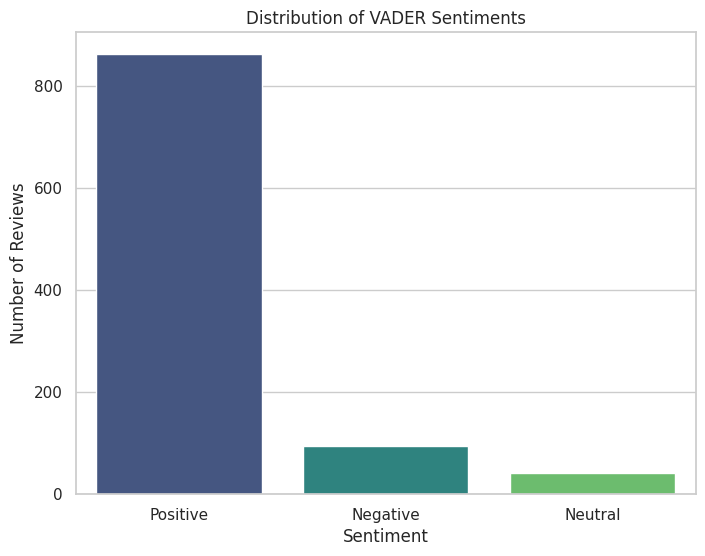

In [40]:
# Display the distribution of VADER sentiments
if 'vader_sentiment' in df.columns:
    sentiment_distribution = df['vader_sentiment'].value_counts()
    print("\nDistribution of VADER Sentiments:")
    print(sentiment_distribution)

    # Visualize sentiment distribution
    plt.figure(figsize=(8, 6))
    sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette='viridis')
    plt.title('Distribution of VADER Sentiments')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Reviews')
    plt.show()
else:
    print("No 'vader_sentiment' column found to display distribution.")

### 4.4. Sentiment and Overall Rating Correlation (if 'overall' column exists)


Correlation between VADER compound score and 'overall' rating:
Pearson correlation: 0.29


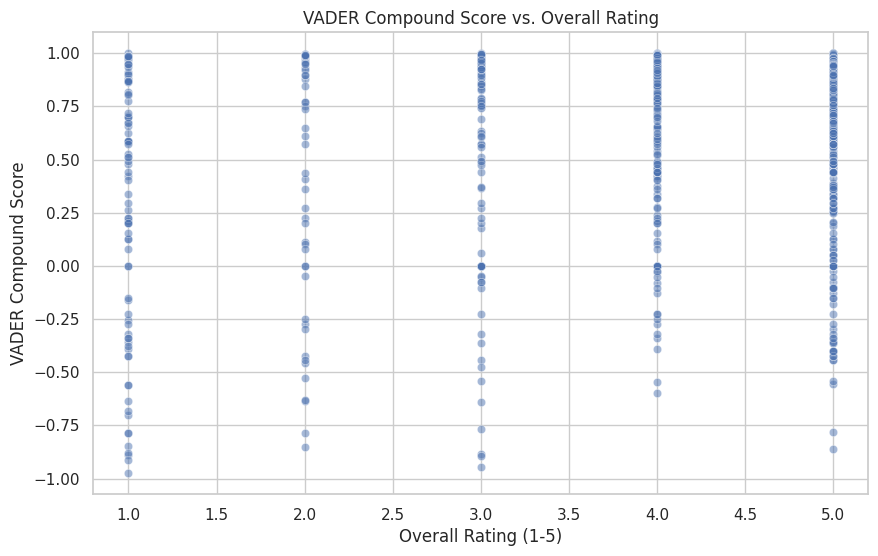

In [41]:
if 'overall' in df.columns and 'vader_compound' in df.columns:
    print("\nCorrelation between VADER compound score and 'overall' rating:")
    correlation = df['vader_compound'].corr(df['overall'])
    print(f"Pearson correlation: {correlation:.2f}")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='overall', y='vader_compound', data=df, alpha=0.5)
    plt.title('VADER Compound Score vs. Overall Rating')
    plt.xlabel('Overall Rating (1-5)')
    plt.ylabel('VADER Compound Score')
    plt.grid(True)
    plt.show()
else:
    print("Skipping correlation analysis: 'overall' or 'vader_compound' column not found.")

## 5. Data Visualization: Uncovering Sentiment Patterns and Trends

Data visualization is crucial for understanding the sentiment analysis results. It helps in identifying patterns, trends, and key drivers of sentiment. In this section, we will create various plots to represent our findings.

### 5.1. Overall Sentiment Distribution

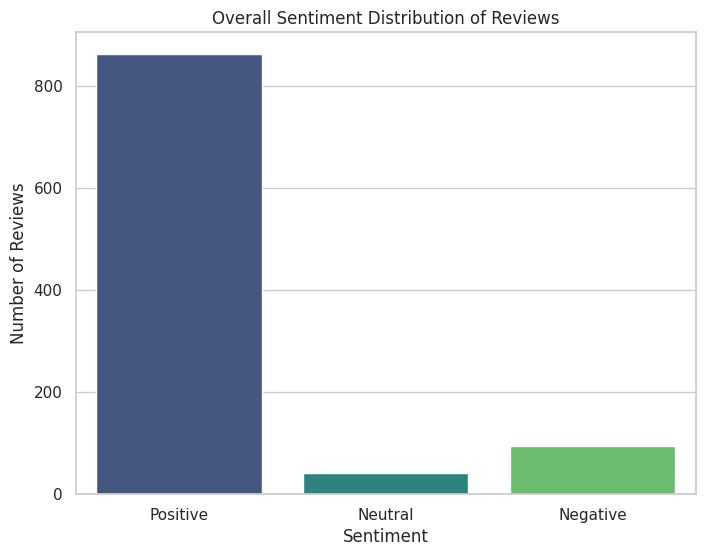

In [43]:
# Re-visualize sentiment distribution for clarity and consistency
if 'vader_sentiment' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='vader_sentiment', data=df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])
    plt.title('Overall Sentiment Distribution of Reviews')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Reviews')
    plt.show()
else:
    print("Cannot plot overall sentiment distribution: 'vader_sentiment' column not found.")


### 5.2. Sentiment Distribution by Overall Rating

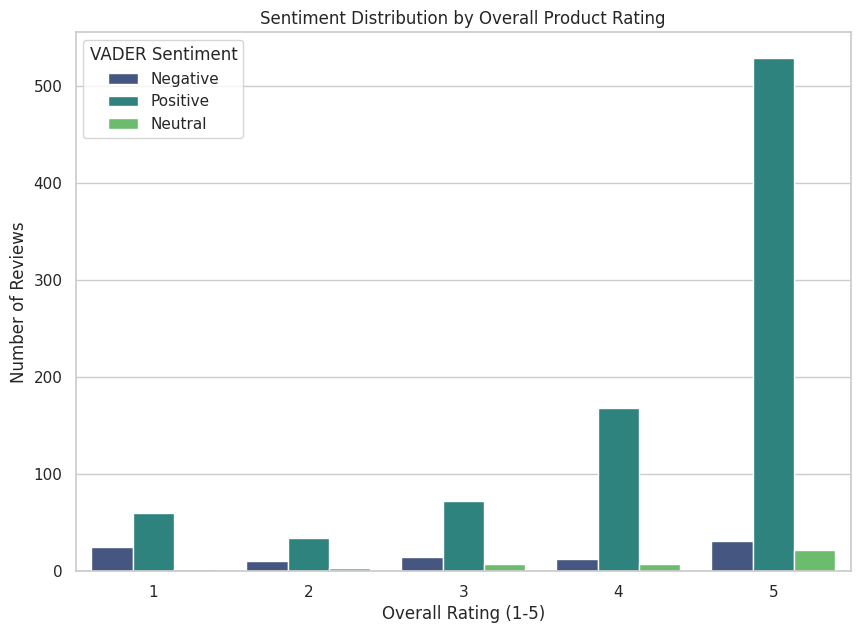

In [44]:
if 'overall' in df.columns and 'vader_sentiment' in df.columns:
    plt.figure(figsize=(10, 7))
    sns.countplot(x='overall', hue='vader_sentiment', data=df, palette='viridis', order=sorted(df['overall'].unique()))
    plt.title('Sentiment Distribution by Overall Product Rating')
    plt.xlabel('Overall Rating (1-5)')
    plt.ylabel('Number of Reviews')
    plt.legend(title='VADER Sentiment')
    plt.show()
else:
    print("Cannot plot sentiment distribution by rating: 'overall' or 'vader_sentiment' column not found.")


### 5.3. Word Clouds for Each Sentiment Category

Word clouds visually represent the most frequent words in a text corpus, with larger words indicating higher frequency. This helps us quickly grasp the prominent themes within positive, neutral, and negative reviews.

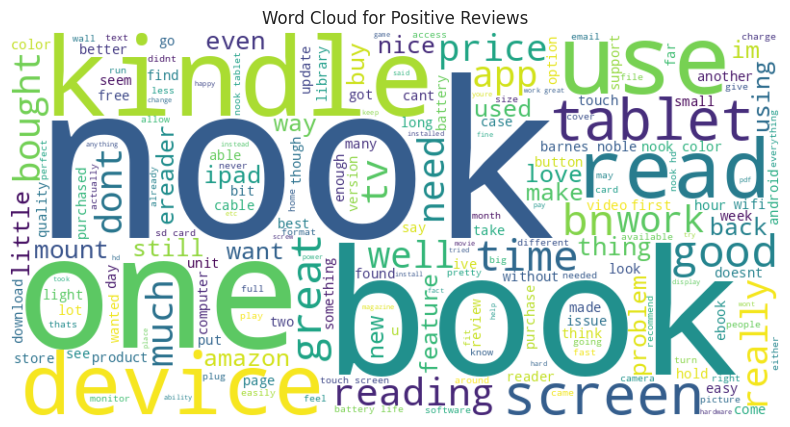

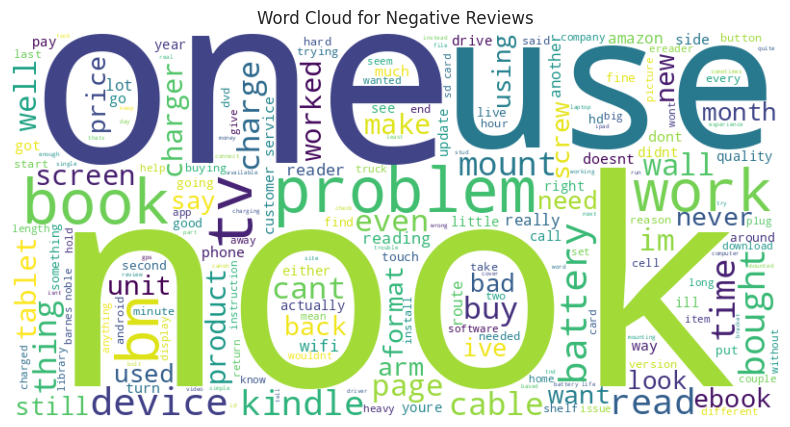

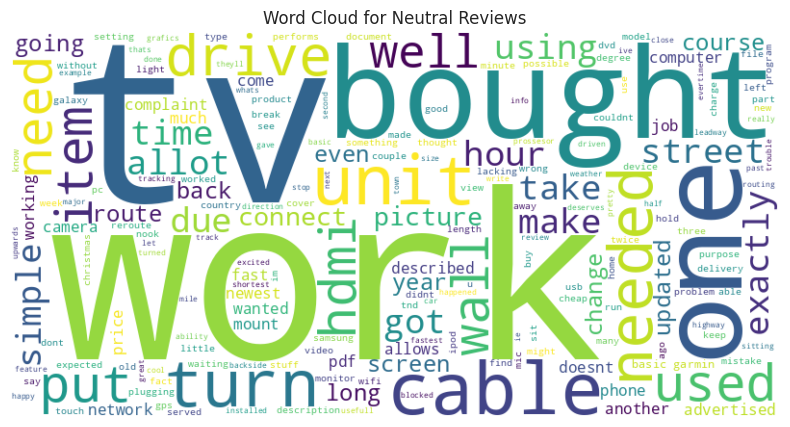

In [45]:
def generate_word_cloud(text, title):
    if not text:
        print(f"No text to generate word cloud for: {title}")
        return
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

if 'cleaned_reviewText' in df.columns and 'vader_sentiment' in df.columns:
    positive_reviews_text = ' '.join(df[df['vader_sentiment'] == 'Positive']['cleaned_reviewText'].dropna())
    negative_reviews_text = ' '.join(df[df['vader_sentiment'] == 'Negative']['cleaned_reviewText'].dropna())
    neutral_reviews_text = ' '.join(df[df['vader_sentiment'] == 'Neutral']['cleaned_reviewText'].dropna())

    generate_word_cloud(positive_reviews_text, 'Word Cloud for Positive Reviews')
    generate_word_cloud(negative_reviews_text, 'Word Cloud for Negative Reviews')
    generate_word_cloud(neutral_reviews_text, 'Word Cloud for Neutral Reviews')
else:
    print("Cannot generate word clouds: 'cleaned_reviewText' or 'vader_sentiment' column not found.")


### 5.4. Most Frequent Words by Sentiment

Beyond word clouds, a bar chart of the most frequent words provides a more precise view of the terminology associated with each sentiment.

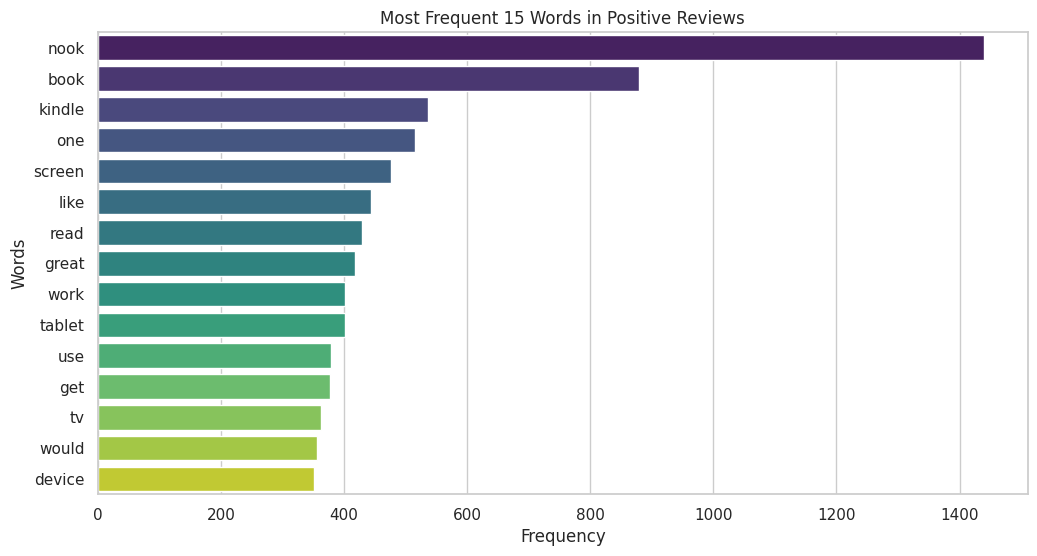

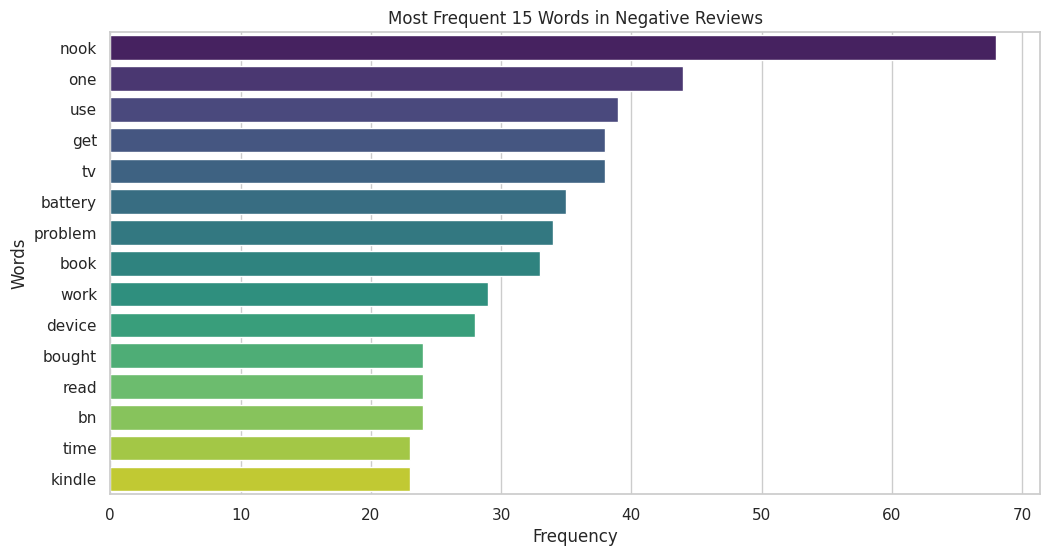

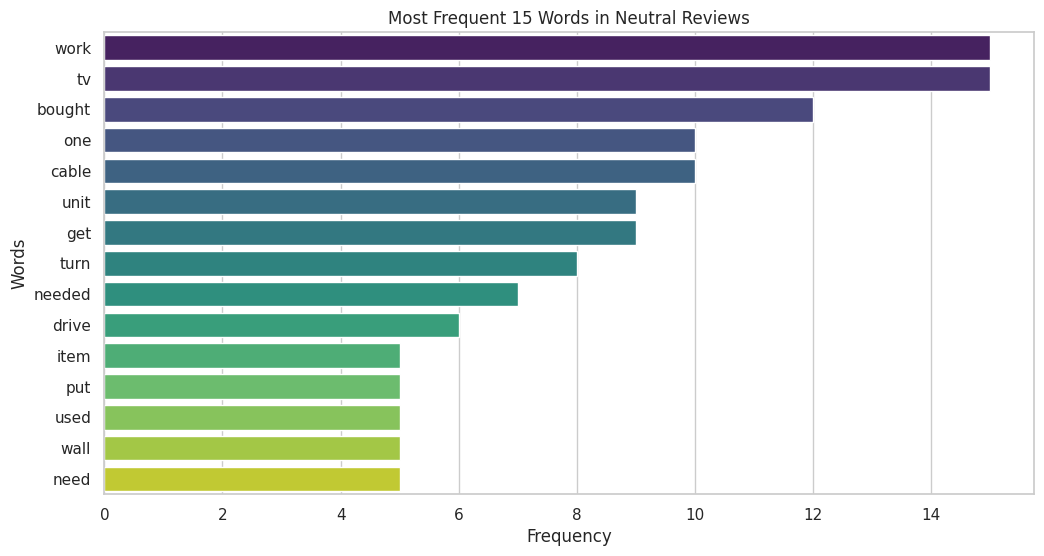

In [46]:
from collections import Counter

def plot_most_frequent_words(text_series, title, top_n=15):
    if text_series.empty:
        print(f"No text data available for '{title}'.")
        return
    all_words = ' '.join(text_series.dropna()).split()
    word_counts = Counter(all_words)
    most_common_words = word_counts.most_common(top_n)

    if not most_common_words:
        print(f"No common words found for '{title}'.")
        return

    words, counts = zip(*most_common_words)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(counts), y=list(words), palette='viridis')
    plt.title(f'Most Frequent {top_n} Words in {title}')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

if 'cleaned_reviewText' in df.columns and 'vader_sentiment' in df.columns:
    plot_most_frequent_words(df[df['vader_sentiment'] == 'Positive']['cleaned_reviewText'], 'Positive Reviews')
    plot_most_frequent_words(df[df['vader_sentiment'] == 'Negative']['cleaned_reviewText'], 'Negative Reviews')
    plot_most_frequent_words(df[df['vader_sentiment'] == 'Neutral']['cleaned_reviewText'], 'Neutral Reviews')
else:
    print("Cannot analyze most frequent words: 'cleaned_reviewText' or 'vader_sentiment' column not found.")


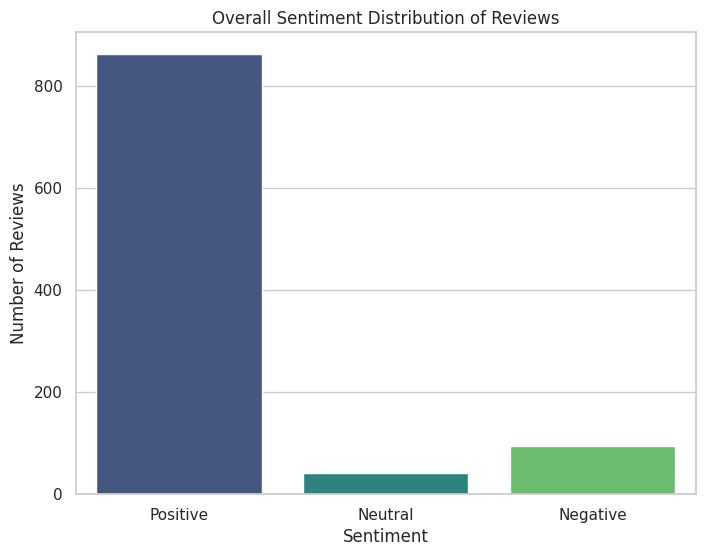

In [47]:
# Re-visualize sentiment distribution for clarity and consistency
if 'vader_sentiment' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='vader_sentiment', data=df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])
    plt.title('Overall Sentiment Distribution of Reviews')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Reviews')
    plt.show()
else:
    print("Cannot plot overall sentiment distribution: 'vader_sentiment' column not found.")


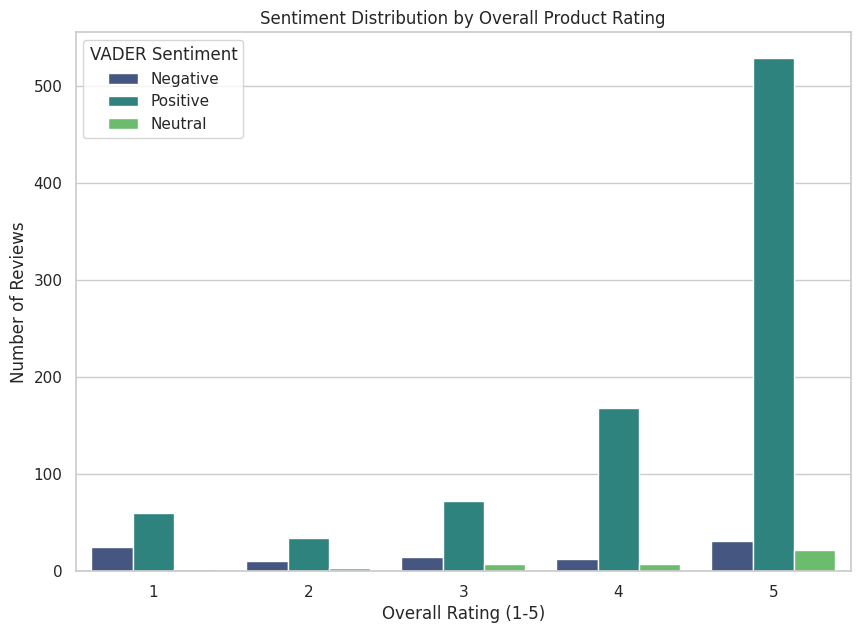

In [48]:
if 'overall' in df.columns and 'vader_sentiment' in df.columns:
    plt.figure(figsize=(10, 7))
    sns.countplot(x='overall', hue='vader_sentiment', data=df, palette='viridis', order=sorted(df['overall'].unique()))
    plt.title('Sentiment Distribution by Overall Product Rating')
    plt.xlabel('Overall Rating (1-5)')
    plt.ylabel('Number of Reviews')
    plt.legend(title='VADER Sentiment')
    plt.show()
else:
    print("Cannot plot sentiment distribution by rating: 'overall' or 'vader_sentiment' column not found.")


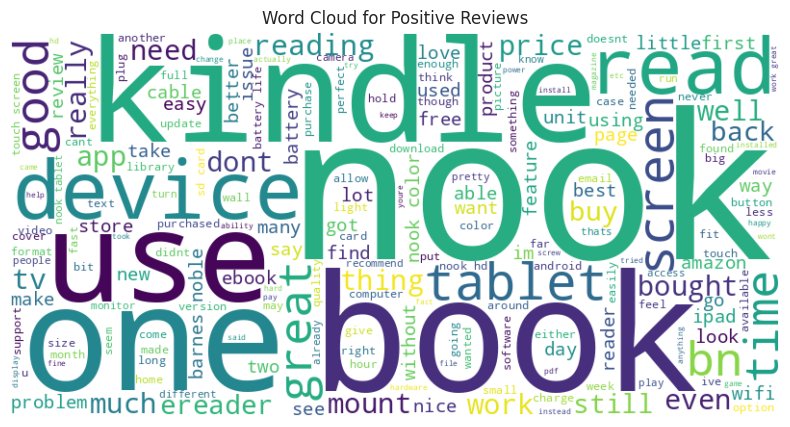

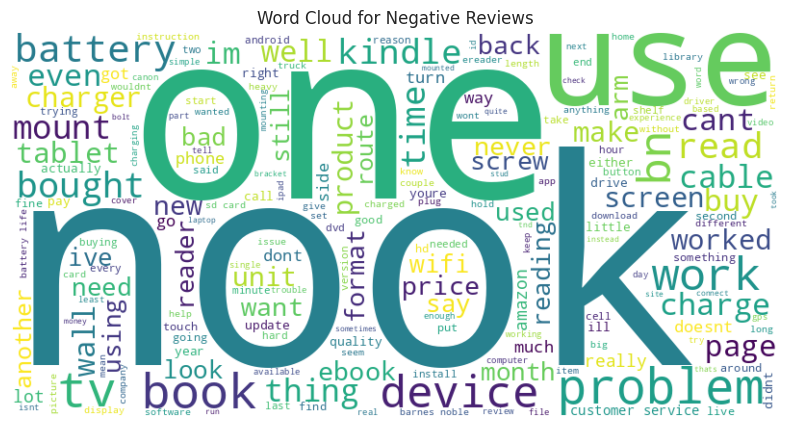

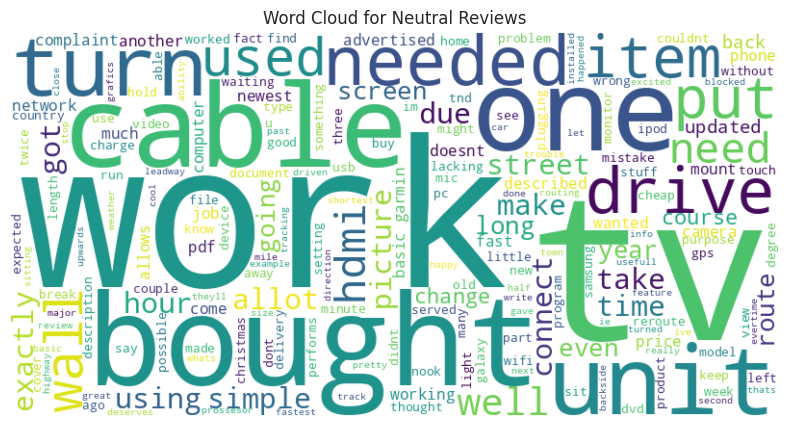

In [49]:
def generate_word_cloud(text, title):
    if not text:
        print(f"No text to generate word cloud for: {title}")
        return
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

if 'cleaned_reviewText' in df.columns and 'vader_sentiment' in df.columns:
    positive_reviews_text = ' '.join(df[df['vader_sentiment'] == 'Positive']['cleaned_reviewText'].dropna())
    negative_reviews_text = ' '.join(df[df['vader_sentiment'] == 'Negative']['cleaned_reviewText'].dropna())
    neutral_reviews_text = ' '.join(df[df['vader_sentiment'] == 'Neutral']['cleaned_reviewText'].dropna())

    generate_word_cloud(positive_reviews_text, 'Word Cloud for Positive Reviews')
    generate_word_cloud(negative_reviews_text, 'Word Cloud for Negative Reviews')
    generate_word_cloud(neutral_reviews_text, 'Word Cloud for Neutral Reviews')
else:
    print("Cannot generate word clouds: 'cleaned_reviewText' or 'vader_sentiment' column not found.")


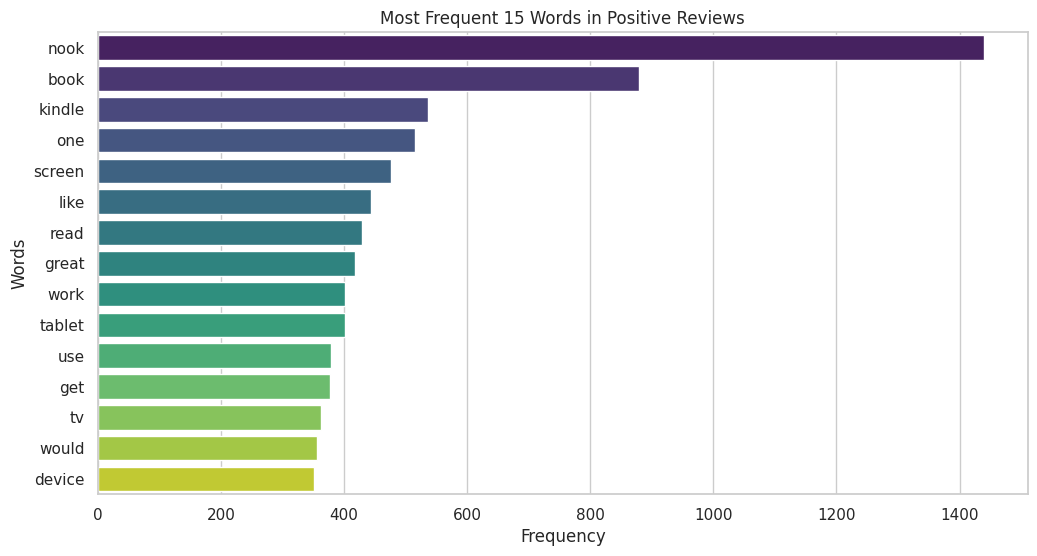

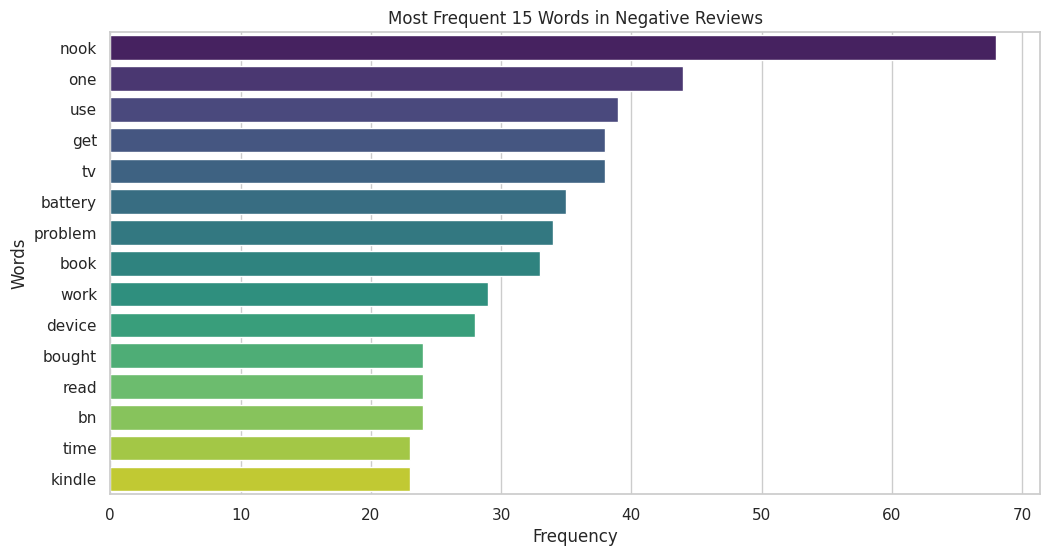

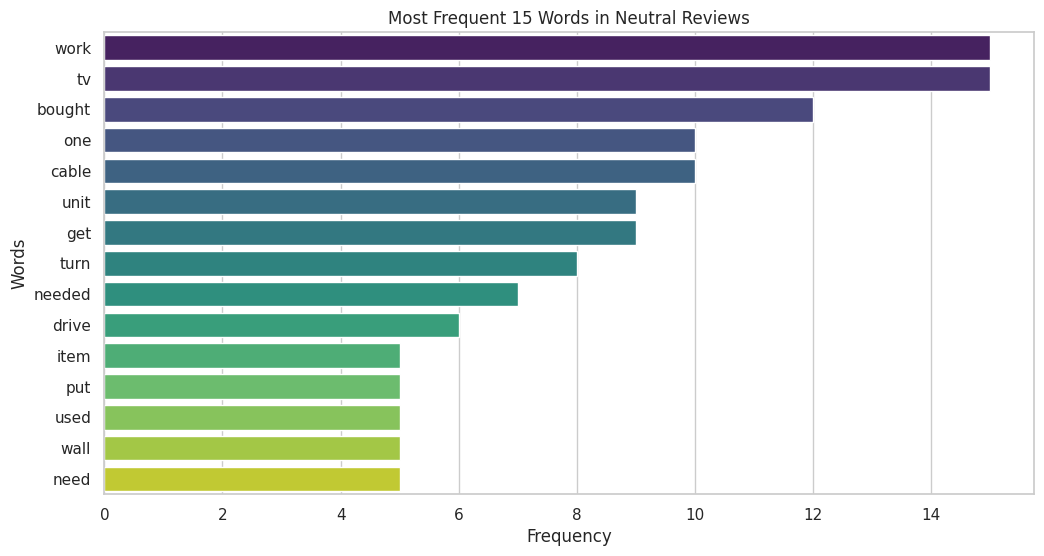

In [50]:
from collections import Counter

def plot_most_frequent_words(text_series, title, top_n=15):
    if text_series.empty:
        print(f"No text data available for '{title}'.")
        return
    all_words = ' '.join(text_series.dropna()).split()
    word_counts = Counter(all_words)
    most_common_words = word_counts.most_common(top_n)

    if not most_common_words:
        print(f"No common words found for '{title}'.")
        return

    words, counts = zip(*most_common_words)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(counts), y=list(words), palette='viridis')
    plt.title(f'Most Frequent {top_n} Words in {title}')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

if 'cleaned_reviewText' in df.columns and 'vader_sentiment' in df.columns:
    plot_most_frequent_words(df[df['vader_sentiment'] == 'Positive']['cleaned_reviewText'], 'Positive Reviews')
    plot_most_frequent_words(df[df['vader_sentiment'] == 'Negative']['cleaned_reviewText'], 'Negative Reviews')
    plot_most_frequent_words(df[df['vader_sentiment'] == 'Neutral']['cleaned_reviewText'], 'Neutral Reviews')
else:
    print("Cannot analyze most frequent words: 'cleaned_reviewText' or 'vader_sentiment' column not found.")


## 6. Data Storytelling & Insights

This section is dedicated to interpreting the visualizations and extracting actionable insights. Based on the plots generated above, we can draw several conclusions about the sentiment patterns in the customer reviews.

### 6.1. Overall Sentiment Landscape

Reflecting on the 'Overall Sentiment Distribution' chart (Section 5.1), we can observe the general emotional tone of the reviews. Is the majority of sentiment positive, negative, or neutral? This gives us a high-level understanding of customer satisfaction.

### 6.2. Sentiment by Product Rating

The 'Sentiment Distribution by Overall Product Rating' chart (Section 5.2) provides a deeper look into how reported sentiment aligns with the numerical star ratings. We can analyze whether lower star ratings consistently correspond to negative sentiment, and higher ratings to positive sentiment. Any discrepancies could highlight interesting areas for further investigation (e.g., sarcastic reviews, or reviews where text sentiment doesn't match the numerical rating).

### 6.3. Key Themes in Sentiment Categories

The word clouds and frequent word analyses for positive, negative, and neutral reviews (Sections 5.3 and 5.4) are powerful tools to understand the specific language and themes associated with each sentiment.

*   **Positive Reviews**: What words frequently appear? These often highlight product strengths, popular features, or aspects that customers love. Look for common descriptors like 'great', 'excellent', 'love', 'easy to use', 'good value'.
*   **Negative Reviews**: What are the recurring complaints or issues? These words point directly to areas needing improvement. Common terms might include 'bad', 'broken', 'disappointed', 'poor quality', 'not working', 'return'.
*   **Neutral Reviews**: What characterizes neutral feedback? These might be functional descriptions, lacking strong emotional language, or words indicating average performance without strong praise or criticism. Terms like 'okay', 'works', 'fine', 'product', 'item' might be common here.

By observing these keywords, we can pinpoint what specifically delights or frustrates customers, or what aspects are simply considered standard.

## 7. Business Recommendations

Based on the sentiment analysis and the insights derived from the visualizations, here are some actionable business recommendations:

### 7.1. Enhance Positive Aspects

*   **Identify and Promote Key Strengths**: Leverage the frequently praised features and aspects (from positive word clouds) in marketing campaigns. Highlight what customers love the most about the product/service.
*   **Encourage Positive Reviews**: Implement strategies to encourage satisfied customers to leave reviews, focusing on the features that consistently receive positive feedback.
*   **Customer Testimonials**: Use excerpts from positive reviews as testimonials on websites, social media, and advertisements to build trust and attract new customers.

### 7.2. Address Negative Feedback

*   **Root Cause Analysis**: Investigate the common themes and words appearing in negative reviews. Is there a recurring issue with product quality, customer support, delivery, or a specific feature?
*   **Product/Service Improvement**: Prioritize fixing critical issues highlighted by negative sentiment. Use the insights to guide product development or service enhancements.
*   **Customer Outreach**: For highly negative reviews, consider proactive customer outreach to resolve issues, turn negative experiences into positive ones, and gather more direct feedback.
*   **FAQs and Support**: Update FAQs and support documentation to address common pain points found in negative reviews.

### 7.3. Understand Neutral Sentiment

*   **Feature Prioritization**: Neutral reviews often describe functional aspects without strong emotion. These can indicate features that are expected but don't differentiate the product. Analyze if these features can be improved to evoke stronger positive sentiment.
*   **Survey for Deeper Insights**: Conduct targeted surveys or interviews with customers who leave neutral reviews to understand what would tip their sentiment towards positive or negative.

### 7.4. Strategic Monitoring

*   **Continuous Sentiment Tracking**: Implement ongoing sentiment monitoring to track changes over time, especially after product updates, marketing campaigns, or competitor actions.
*   **Benchmark Against Competitors**: Apply similar sentiment analysis to competitor reviews to identify market gaps and areas for competitive advantage.

## 8. Conclusion

This Google Colab notebook has demonstrated a comprehensive workflow for sentiment analysis, from initial data loading and preprocessing to advanced sentiment classification, visualization, and actionable insights. By leveraging NLP techniques and sentiment lexicons like VADER and TextBlob, we were able to:

*   **Process raw text data** into a clean and structured format.
*   **Classify sentiments** (Positive, Negative, Neutral) to understand the emotional tone of customer reviews.
*   **Visualize sentiment patterns** and identify key themes associated with different emotional categories.
*   **Derive business recommendations** to enhance positive aspects, address negative feedback, and understand neutral sentiment.

Sentiment analysis is a powerful tool for businesses to monitor brand perception, improve products, and tailor marketing strategies based on real-time customer feedback. The methodologies outlined in this notebook can be adapted to various text-based datasets, offering a versatile approach to understanding public opinion and driving informed decision-making.